In [4]:
!pip install xgboost
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 4.2 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.5 MB/s eta 0:00:00



===== SHAPE OF DATASET =====
(768, 9)

===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

===== STATISTICAL SUMMARY =====
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000 

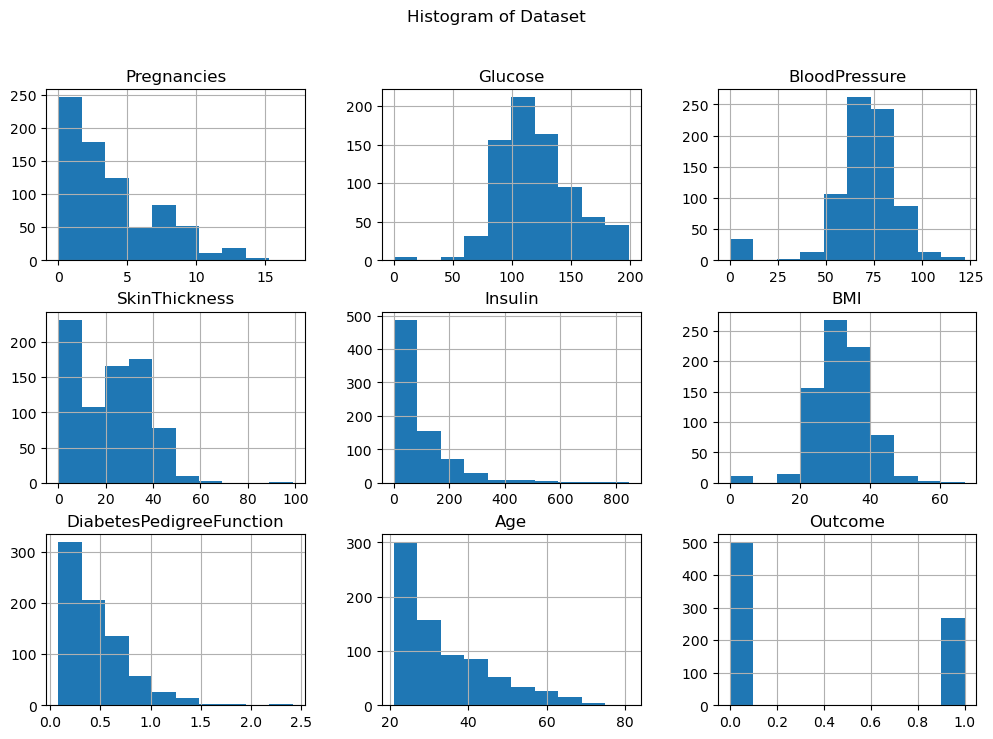

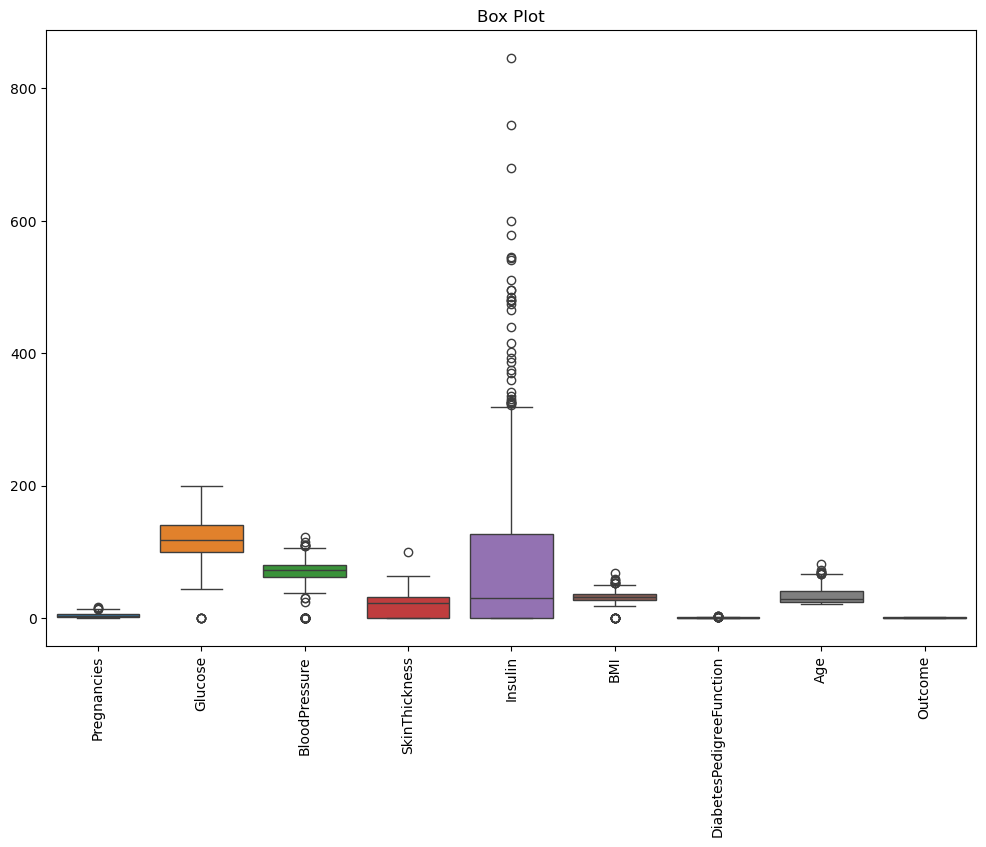

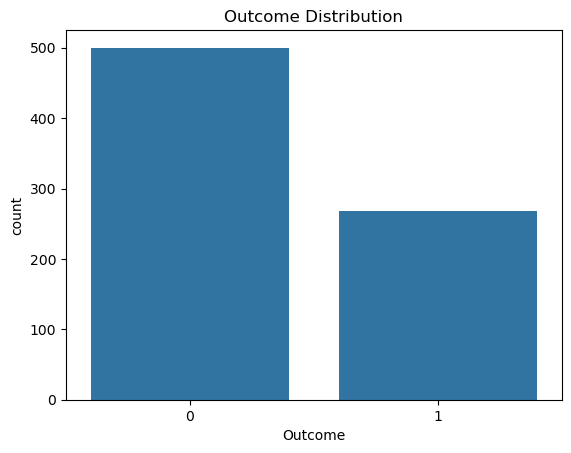

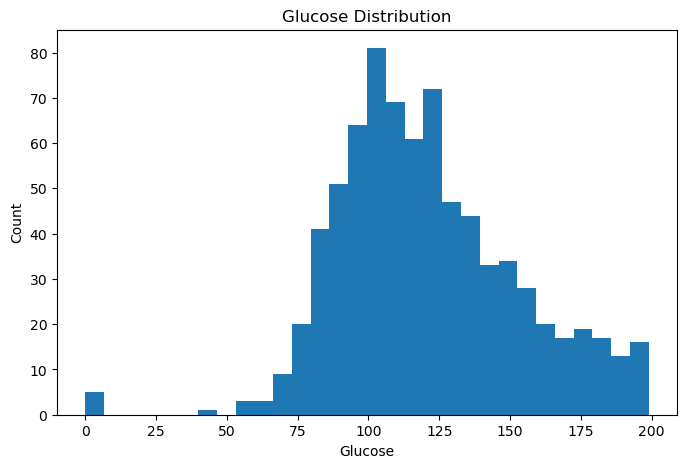

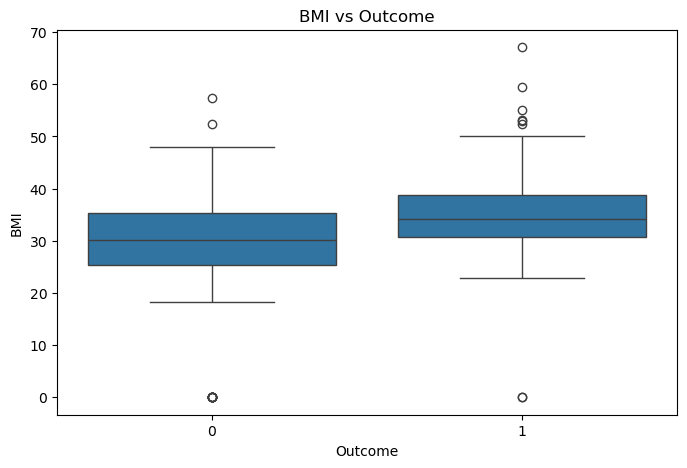

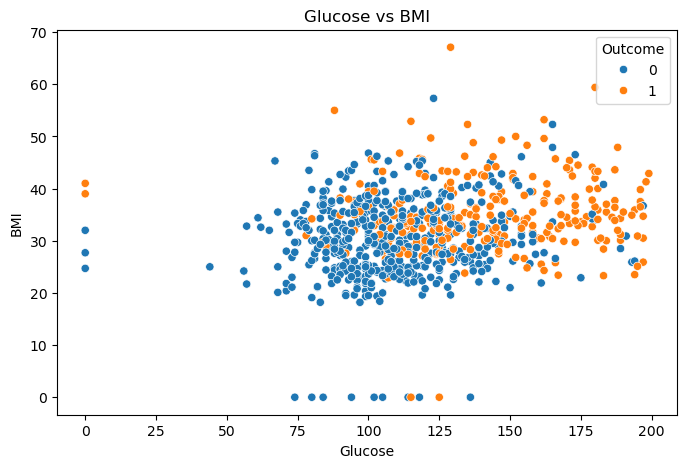

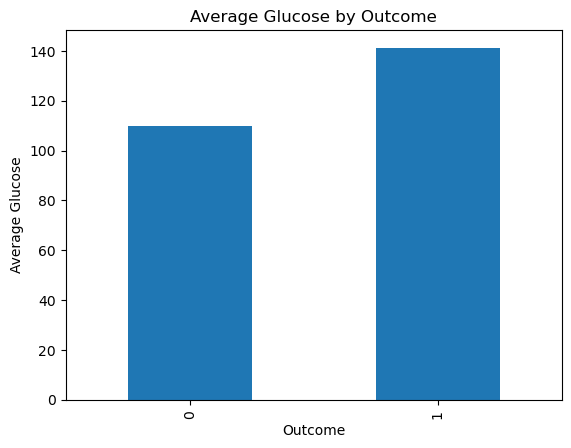

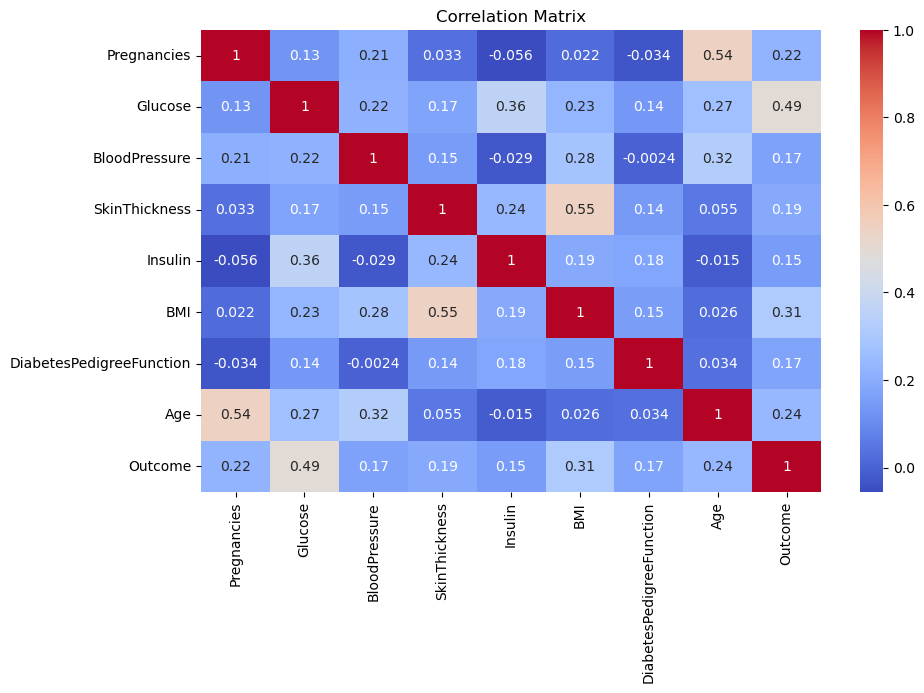


===== XGBOOST MODEL ACCURACY =====
Accuracy Score: 0.7337662337662337

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



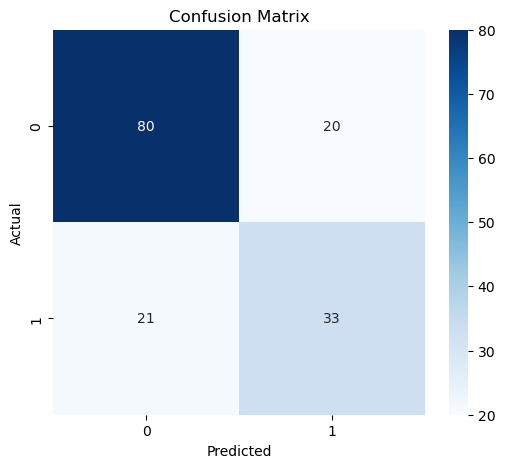

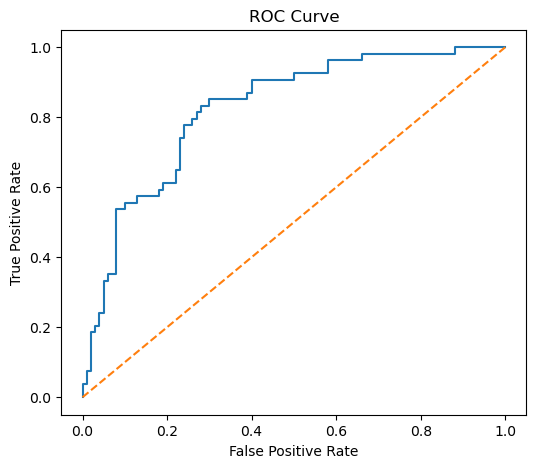

ROC-AUC Score: 0.8235185185185184

===== CROSS VALIDATION =====
CV Mean Accuracy: 0.7475942956150874

===== BEST PARAMETERS =====
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

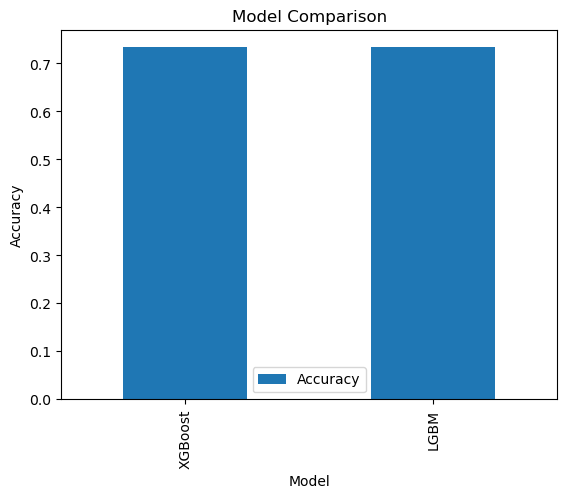

In [1]:
# ==========================================
# DIABETES PREDICTION USING XGBOOST & LGBM
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(
    r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\diabetes.csv"
)

# ==========================================
# Basic Information
# ==========================================

print("\n===== SHAPE OF DATASET =====")
print(df.shape)

print("\n===== DATASET INFO =====")
print(df.info())

print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())

print("\n===== FIRST 5 ROWS =====")
print(df.head())

print("\n===== COLUMN NAMES =====")
print(df.columns)

print("\n===== NULL VALUES =====")
print(df.isnull().sum())

# ==========================================
# Data Visualization
# ==========================================

# Histogram
df.hist(figsize=(12,8))

plt.suptitle("Histogram of Dataset")

plt.show()

# Box Plot
plt.figure(figsize=(12,8))

sns.boxplot(data=df)

plt.title("Box Plot")

plt.xticks(rotation=90)

plt.show()

# ==========================================
# Outcome Distribution
# ==========================================

sns.countplot(x='Outcome', data=df)

plt.title("Outcome Distribution")

plt.show()

# ==========================================
# Glucose Distribution
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(df['Glucose'], bins=30)

plt.title("Glucose Distribution")

plt.xlabel("Glucose")

plt.ylabel("Count")

plt.show()

# ==========================================
# BMI vs Outcome
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='BMI', data=df)

plt.title("BMI vs Outcome")

plt.show()

# ==========================================
# Scatter Plot
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.title("Glucose vs BMI")

plt.show()

# ==========================================
# Bar Plot
# ==========================================

df.groupby("Outcome")["Glucose"].mean().plot(
    kind='bar'
)

plt.title("Average Glucose by Outcome")

plt.ylabel("Average Glucose")

plt.show()

# ==========================================
# Handle Missing Values
# ==========================================

cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in cols:
    df[col] = df[col].replace(
        0,
        df[col].median()
    )

# ==========================================
# Correlation Matrix
# ==========================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# ==========================================
# Define Features and Target
# ==========================================

X = df.drop('Outcome', axis=1)

y = df['Outcome']

# ==========================================
# Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ==========================================
# Build XGBoost Model
# ==========================================

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# ==========================================
# Prediction
# ==========================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

# ==========================================
# Evaluation Metrics
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("\n===== XGBOOST MODEL ACCURACY =====")

print(
    "Accuracy Score:",
    accuracy_score(y_test, y_pred)
)

print("\n===== CLASSIFICATION REPORT =====")

print(classification_report(y_test, y_pred))

# ==========================================
# Confusion Matrix
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], '--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# ==========================================
# ROC-AUC Score
# ==========================================

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, y_prob)
)

# ==========================================
# CROSS VALIDATION
# ==========================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("\n===== CROSS VALIDATION =====")

print("CV Mean Accuracy:", cv_scores.mean())

# ==========================================
# HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,4],
    'learning_rate': [0.01,0.05],
    'n_estimators': [100,200]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("\n===== BEST PARAMETERS =====")

print(grid.best_params_)

# ==========================================
# LGBM MODEL
# ==========================================

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

print("\n===== LGBM RESULTS =====")

print(
    "Accuracy:",
    accuracy_score(y_test, lgbm_pred)
)

print(classification_report(y_test, lgbm_pred))

# ==========================================
# MODEL COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Model": ["XGBoost", "LGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, lgbm_pred)
    ]
})

print("\n===== MODEL COMPARISON =====")

print(comparison)

# ==========================================
# COMPARISON VISUALIZATION
# ==========================================

comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

XGBoost successfully predicted diabetes with good accuracy and ROC-AUC score.
Glucose, BMI, and Age were the most influential features.
The model performs well for medical classification problems.
